# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Shava Selvia R.S
- **Email:** shashava05@gmail.com
- **ID Dicoding:** shavel28

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perkembangan jumlah pesanan dan total nilai penjualan per bulan selama periode September 2016–Agustus 2018, dan bulan mana yang memiliki nilai penjualan tertinggi?
- **Pertanyaan 2:** Kategori produk apa yang menghasilkan nilai penjualan terbesar selama periode September 2016–Agustus 2018, dan seberapa besar kontribusinya terhadap total nilai penjualan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Data Wrangling

### Gathering Data

#### Load df

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/submission/data'

print("Isi folder dataset:")
print(os.listdir(data_path))

Mounted at /content/drive
Isi folder dataset:
['customers_dataset.csv', 'order_payments_dataset.csv', 'order_items_dataset.csv', 'geolocation_dataset.csv', 'order_reviews_dataset.csv', 'New Text Document.txt', 'products_dataset.csv', 'orders_dataset.csv', 'sellers_dataset.csv', 'product_category_name_translation.csv']


In [3]:
orders = pd.read_csv(data_path + '/orders_dataset.csv')
order_items = pd.read_csv(data_path + '/order_items_dataset.csv')
order_payments = pd.read_csv(data_path + '/order_payments_dataset.csv')
order_reviews = pd.read_csv(data_path + '/order_reviews_dataset.csv')
products = pd.read_csv(data_path + '/products_dataset.csv')
sellers = pd.read_csv(data_path + '/sellers_dataset.csv')
geolocation = pd.read_csv(data_path + '/geolocation_dataset.csv')
translation = pd.read_csv(data_path + '/product_category_name_translation.csv')
customers = pd.read_csv(data_path + '/customers_dataset.csv')

print("Semua dataset berhasil dimuat.")
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Order Payments:", order_payments.shape)
print("Order Reviews:", order_reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Translation:", translation.shape)

Semua dataset berhasil dimuat.
Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Geolocation: (1000163, 5)
Translation: (71, 2)


**Insight:** (Opsional)

- Dataset terdiri dari beberapa tabel yang saling berkaitan untuk menggambarkan proses transaksi e-commerce.
- Dataset `orders` digunakan untuk menganalisis waktu dan status pesanan.
- Dataset `order_items` digunakan untuk memperoleh harga produk dan biaya pengiriman.
- Dataset `products` dan `product_category_name_translation` digunakan untuk mengetahui kategori produk.
- Dataset `customers` digunakan pada analisis lanjutan RFM agar identitas pelanggan dihitung berdasarkan `customer_unique_id`, bukan `customer_id`.

### Assessing Data

#### Identifying Data Quality Problems

In [4]:
# 1. Memeriksa struktur dan tipe data
print("=== INFORMASI DATA ===")
print("\nORDERS")
orders.info()

print("\nORDER ITEMS")
order_items.info()

print("\nPRODUCTS")
products.info()

# 2. Memeriksa missing value
print("\n=== MISSING VALUE ===")
print("\nOrders:")
display(orders.isna().sum().sort_values(ascending=False))

print("\nOrder Items:")
display(order_items.isna().sum().sort_values(ascending=False))

print("\nProducts:")
display(products.isna().sum().sort_values(ascending=False))

# 3. Memeriksa duplicate
print("\n=== DUPLICATE DATA ===")
print("Orders:", orders.duplicated().sum())
print("Order Items:", order_items.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Payments:", order_payments.duplicated().sum())
print("Reviews:", order_reviews.duplicated().sum())
print("Customers:", customers.duplicated().sum())

# 4. Memeriksa statistik numerik dan potensi outlier
print("\n=== STATISTIK NUMERIK ORDER ITEMS ===")
display(order_items[['price', 'freight_value']].describe())

q1 = order_items['price'].quantile(0.25)
q3 = order_items['price'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)
outlier_price_count = (order_items['price'] > upper_bound).sum()

print(f"Potensi outlier price berdasarkan IQR: {outlier_price_count} baris")
print(f"Batas atas IQR: {upper_bound:.2f}")

# 5. Memeriksa tipe kolom tanggal
print("\n=== TIPE DATA TANGGAL ===")
display(
    orders[
        [
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ].dtypes
)

=== INFORMASI DATA ===

ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

ORDER ITEMS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   o

,0
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
order_approved_at,160
order_id,0
order_purchase_timestamp,0
order_status,0
customer_id,0
order_estimated_delivery_date,0



Order Items:


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0



Products:


,0
product_category_name,610
product_description_lenght,610
product_name_lenght,610
product_photos_qty,610
product_weight_g,2
product_height_cm,2
product_length_cm,2
product_width_cm,2
product_id,0



=== DUPLICATE DATA ===
Orders: 0
Order Items: 0
Products: 0
Payments: 0
Reviews: 0
Customers: 0

=== STATISTIK NUMERIK ORDER ITEMS ===


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


Potensi outlier price berdasarkan IQR: 8427 baris
Batas atas IQR: 277.40

=== TIPE DATA TANGGAL ===


,0
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object


**Steps to Take:**

- Mengonversi seluruh kolom tanggal pada dataset `orders` menjadi tipe `datetime`.
- Menghapus data duplikat apabila ditemukan.
- Menangani missing value pada `product_category_name` dengan label `unknown`.
- Missing value pada tanggal pengiriman tidak diimputasi karena dapat menunjukkan pesanan yang belum menyelesaikan proses pengiriman dan kolom tersebut tidak menjadi dasar utama analisis penjualan.
- Memeriksa potensi outlier pada `price`. Nilai yang sangat tinggi tidak langsung dihapus karena dapat merupakan transaksi produk dengan harga tinggi yang valid.
- Hanya pesanan dengan status `delivered` yang digunakan dalam analisis penjualan agar nilai penjualan merepresentasikan transaksi yang berhasil diselesaikan.

**Insight:**

- Ditemukan missing value pada beberapa kolom, terutama informasi pengiriman pada `orders` dan atribut produk pada `products`.
- Kolom tanggal pada `orders` masih bertipe `object` sehingga perlu dikonversi menjadi `datetime`.
- Tidak ditemukan data duplikat pada tabel utama yang diperiksa.
- Nilai maksimum `price` jauh lebih tinggi dibandingkan kuartil data sehingga teridentifikasi sebagai potensi outlier. Nilai tersebut tidak langsung dihapus karena belum dapat dinyatakan sebagai kesalahan data tanpa konteks bisnis.

### Cleaning Data

#### Fixing Identified Data Quality Problems

In [5]:
# Membuat salinan dataset
orders_clean = orders.copy()
order_items_clean = order_items.copy()
order_payments_clean = order_payments.copy()
order_reviews_clean = order_reviews.copy()
products_clean = products.copy()
customers_clean = customers.copy()

# Menghapus data duplikat
orders_clean.drop_duplicates(inplace=True)
order_items_clean.drop_duplicates(inplace=True)
order_payments_clean.drop_duplicates(inplace=True)
order_reviews_clean.drop_duplicates(inplace=True)
products_clean.drop_duplicates(inplace=True)
customers_clean.drop_duplicates(inplace=True)

# Konversi kolom tanggal
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in date_columns:
    orders_clean[column] = pd.to_datetime(
        orders_clean[column],
        errors='coerce'
    )

# Menangani missing value kategori produk
products_clean['product_category_name'] = (
    products_clean['product_category_name']
    .fillna('unknown')
)

# Menggabungkan terjemahan kategori produk
products_clean = products_clean.merge(
    translation,
    on='product_category_name',
    how='left'
)

products_clean['product_category_name_english'] = (
    products_clean['product_category_name_english']
    .fillna('unknown')
)

print("Cleaning data selesai.")

Cleaning data selesai.


In [6]:
print("=== HASIL CLEANING ===")
print("Duplicate Orders:", orders_clean.duplicated().sum())
print("Duplicate Order Items:", order_items_clean.duplicated().sum())
print("Duplicate Products:", products_clean.duplicated().sum())
print("Duplicate Customers:", customers_clean.duplicated().sum())

print("\nTipe data tanggal:")
display(
    orders_clean[
        [
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ].dtypes
)

print("\nMissing value kategori produk setelah cleaning:")
print(products_clean['product_category_name'].isna().sum())

=== HASIL CLEANING ===
Duplicate Orders: 0
Duplicate Order Items: 0
Duplicate Products: 0
Duplicate Customers: 0

Tipe data tanggal:


,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]



Missing value kategori produk setelah cleaning:
0


**Insight:** (Opsional)

- Data duplikat pada dataset yang digunakan telah diperiksa dan dihapus.
- Seluruh kolom tanggal yang diperlukan telah dikonversi menjadi tipe `datetime`.
- Missing value pada `product_category_name` telah ditangani dengan label `unknown`.
- Potensi outlier pada `price` dipertahankan karena belum terbukti sebagai kesalahan data.
- Dataset hasil cleaning siap digunakan untuk proses EDA.

## Exploratory Data Analysis (EDA)

### Explore Monthly Sales Performance and Product Categories

In [7]:
# Menggabungkan orders dengan order_items
sales = orders_clean.merge(
    order_items_clean,
    on='order_id',
    how='inner'
)

# Menggabungkan dengan products
sales = sales.merge(
    products_clean[
        [
            'product_id',
            'product_category_name_english'
        ]
    ],
    on='product_id',
    how='left'
)

# Hanya menggunakan pesanan yang berhasil diselesaikan
sales = sales[
    sales['order_status'] == 'delivered'
].copy()

# Menghitung nilai penjualan dari harga produk + biaya pengiriman
sales['sales_value'] = (
    sales['price'] +
    sales['freight_value']
)

# Membuat periode bulan
sales['month'] = (
    sales['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

print("Jumlah baris setelah penggabungan:", len(sales))
print("Jumlah order:", sales['order_id'].nunique())
print("Jumlah customer_id:", sales['customer_id'].nunique())
print("Periode analisis:", sales['month'].min(), "sampai", sales['month'].max())

display(sales.head())

# EDA Pertanyaan 1
monthly_sales = (
    sales.groupby('month')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_sales=('sales_value', 'sum')
    )
    .reset_index()
)

display(monthly_sales)

# EDA Pertanyaan 2
category_sales = (
    sales
    .groupby('product_category_name_english')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_sales=('sales_value', 'sum')
    )
    .reset_index()
    .sort_values(
        'total_sales',
        ascending=False
    )
)

category_sales['contribution_percentage'] = (
    category_sales['total_sales']
    / category_sales['total_sales'].sum()
    * 100
)

display(category_sales.head(10))

Jumlah baris setelah penggabungan: 110197
Jumlah order: 96478
Jumlah customer_id: 96478
Periode analisis: 2016-09 sampai 2018-08


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,sales_value,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,stationery,28.62,2018-02


,month,total_orders,total_sales
0,2016-09,1,143.46
1,2016-10,265,46490.66
2,2016-12,1,19.62
3,2017-01,750,127482.37
4,2017-02,1653,271239.32
5,2017-03,2546,414330.95
6,2017-04,2303,390812.40
7,2017-05,3546,566851.40
8,2017-06,3135,490050.37
9,2017-07,3872,566299.08


,product_category_name_english,total_orders,total_sales,contribution_percentage
43,health_beauty,8647,1412089.53,9.157654
71,watches_gifts,5495,1264333.12,8.199427
7,bed_bath_table,9272,1225209.26,7.945702
65,sports_leisure,7530,1118256.91,7.252097
15,computers_accessories,6530,1032723.77,6.697399
39,furniture_decor,6307,880329.92,5.709098
49,housewares,5743,758392.25,4.918310
20,cool_stuff,3559,691680.89,4.485675
5,auto,3810,669454.75,4.341534
42,garden_tools,3448,567145.68,3.678042


**Insight:** (Opsional)

- Data penjualan berhasil diagregasi berdasarkan bulan dan kategori produk.
- Periode aktual yang dianalisis adalah September 2016 hingga Agustus 2018 karena analisis hanya menggunakan pesanan berstatus `delivered`.
- Agregasi bulanan digunakan untuk menjawab pertanyaan mengenai perkembangan jumlah pesanan dan nilai penjualan.
- Agregasi kategori digunakan untuk mengetahui kategori dengan nilai penjualan dan kontribusi terbesar.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Bagaimana perkembangan jumlah pesanan dan total nilai penjualan per bulan selama periode September 2016–Agustus 2018, dan bulan mana yang memiliki nilai penjualan tertinggi?

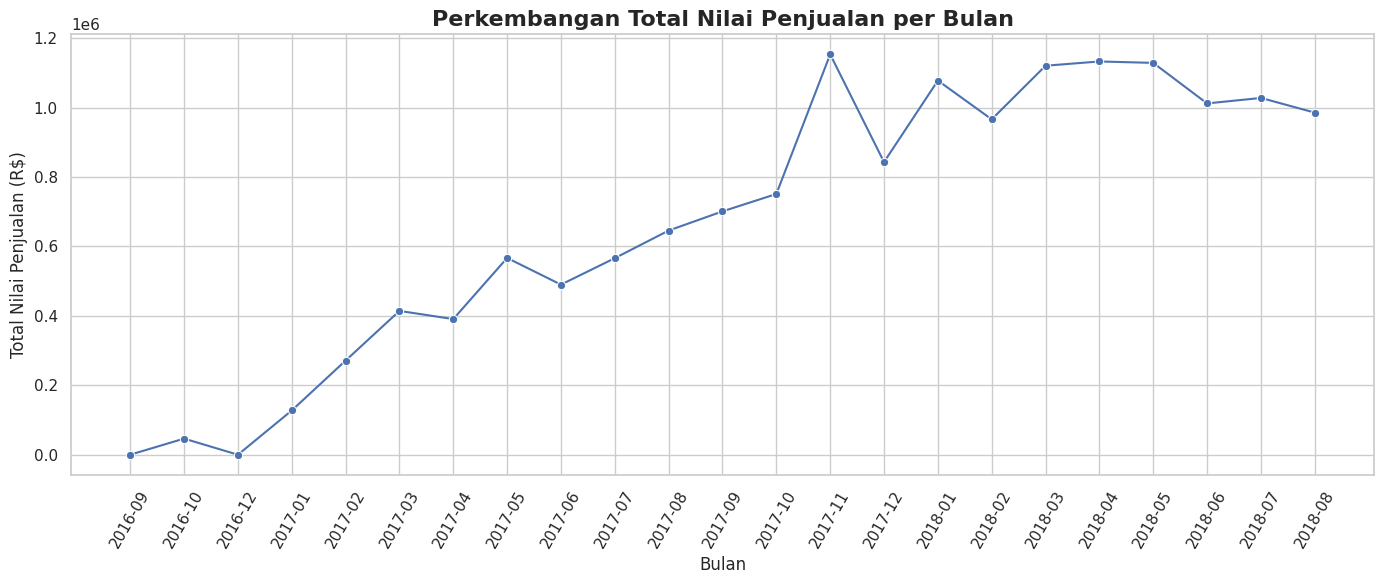

Bulan dengan nilai penjualan tertinggi: 2017-11
Total nilai penjualan: R$ 1,153,364.20


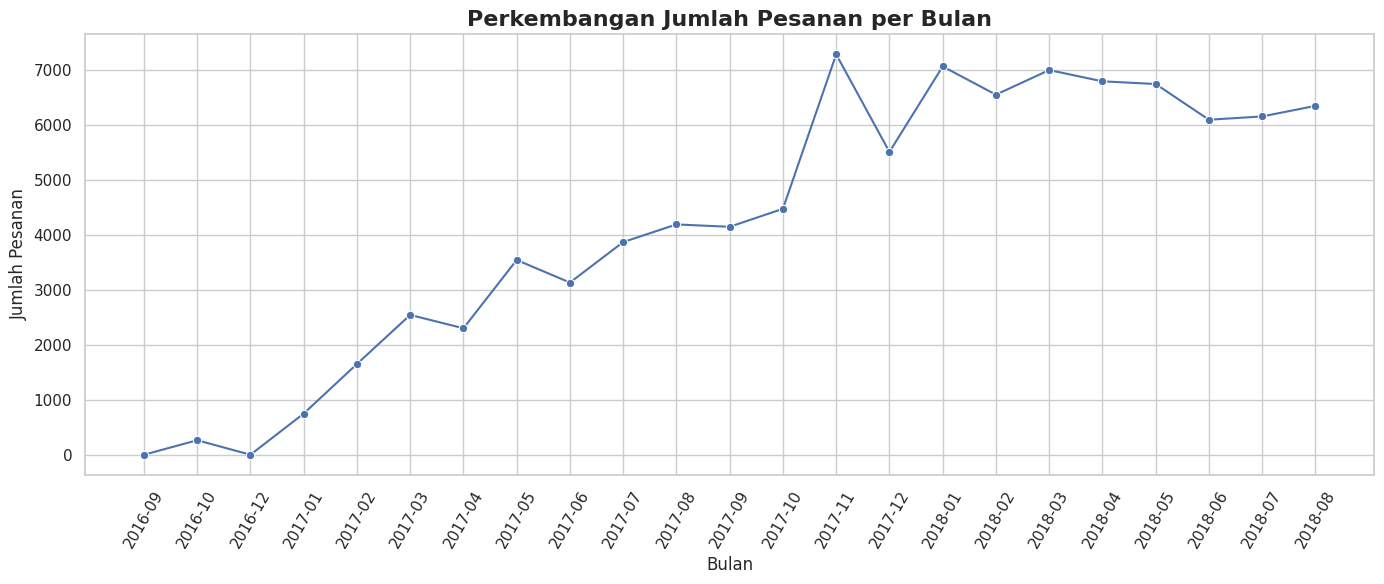

In [8]:
# Visualisasi total nilai penjualan per bulan
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='total_sales',
    marker='o'
)

plt.title(
    'Perkembangan Total Nilai Penjualan per Bulan',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Bulan')
plt.ylabel('Total Nilai Penjualan (R$)')
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

highest_month = monthly_sales.loc[
    monthly_sales['total_sales'].idxmax()
]

print(
    "Bulan dengan nilai penjualan tertinggi:",
    highest_month['month']
)

print(
    f"Total nilai penjualan: R$ {highest_month['total_sales']:,.2f}"
)

# Visualisasi jumlah pesanan per bulan
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='total_orders',
    marker='o'
)

plt.title(
    'Perkembangan Jumlah Pesanan per Bulan',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

Kategori produk apa yang menghasilkan nilai penjualan terbesar selama periode September 2016–Agustus 2018, dan seberapa besar kontribusinya terhadap total nilai penjualan?

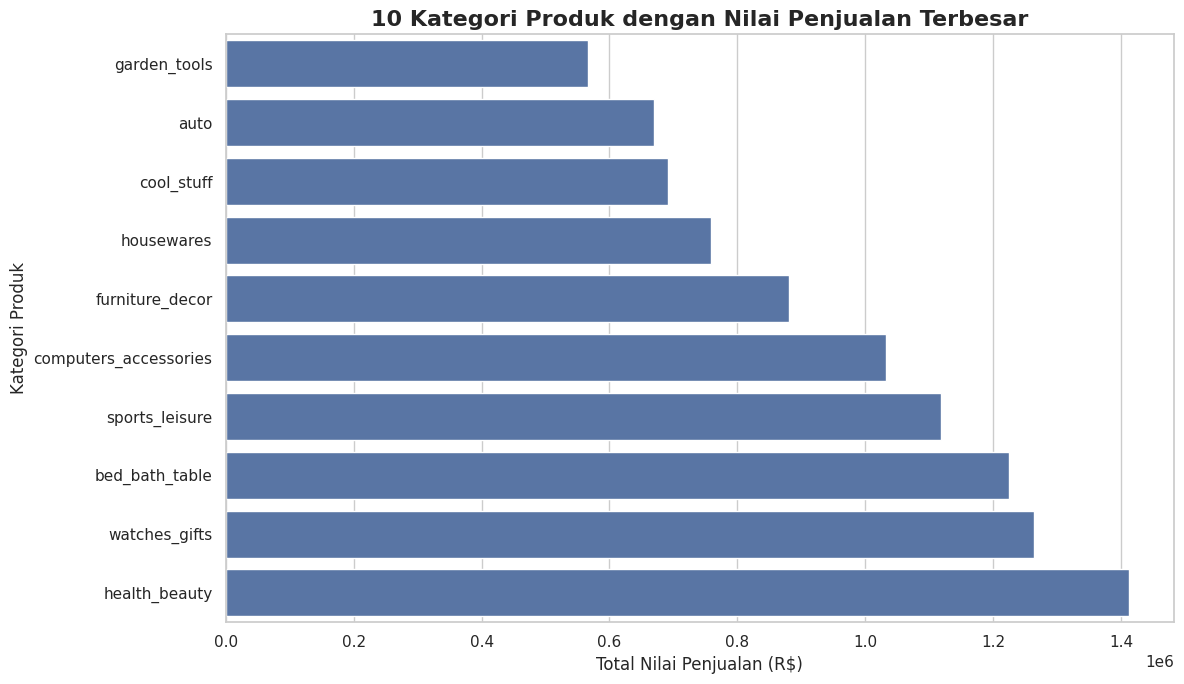

Kategori dengan nilai penjualan terbesar: health_beauty
Total nilai penjualan: R$ 1,412,089.53
Kontribusi terhadap total: 9.16%


In [9]:
top10_category = (
    category_sales
    .head(10)
    .sort_values(
        'total_sales',
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top10_category,
    x='total_sales',
    y='product_category_name_english'
)

plt.title(
    '10 Kategori Produk dengan Nilai Penjualan Terbesar',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Total Nilai Penjualan (R$)')
plt.ylabel('Kategori Produk')

plt.tight_layout()
plt.show()

top_category = category_sales.iloc[0]

print(
    "Kategori dengan nilai penjualan terbesar:",
    top_category['product_category_name_english']
)

print(
    f"Total nilai penjualan: R$ {top_category['total_sales']:,.2f}"
)

print(
    f"Kontribusi terhadap total: "
    f"{top_category['contribution_percentage']:.2f}%"
)

**Insight:** (Opsional)

- Nilai penjualan mengalami perubahan dari bulan ke bulan dan mencapai nilai tertinggi pada **November 2017**, yaitu sebesar **R$ 1.153.364,20**.
- Jumlah pesanan juga menunjukkan perubahan sepanjang periode pengamatan, dengan peningkatan aktivitas transaksi yang cukup besar pada periode 2017–2018.
- Kategori **health_beauty** memiliki nilai penjualan terbesar, yaitu **R$ 1.412.089,53**.
- Kontribusi kategori **health_beauty** terhadap total nilai penjualan adalah sekitar **9,16%**.

## Analisis Lanjutan (Opsional)

RFM Analysis digunakan untuk memahami perilaku pelanggan berdasarkan tiga indikator:

- **Recency:** jumlah hari sejak transaksi terakhir pelanggan.
- **Frequency:** jumlah transaksi yang dilakukan pelanggan.
- **Monetary:** total nilai penjualan pelanggan.

Untuk menghindari kesalahan identitas pelanggan, analisis menggunakan `customer_unique_id` dari `customers_dataset.csv`. Kolom `customer_id` pada dataset Olist merupakan identitas yang terkait dengan pesanan, sehingga bukan pilihan yang tepat untuk menghitung pelanggan unik pada RFM.

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Potential Loyalists
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,Lost Customers


,Segment,Customers,Percentage
0,At Risk,22357,23.947600
1,Needs Attention,18672,20.000428
2,Loyal Customers,15904,17.035498
3,Lost Customers,14986,16.052186
4,Potential Loyalists,14984,16.050044
5,Champions,6455,6.914244


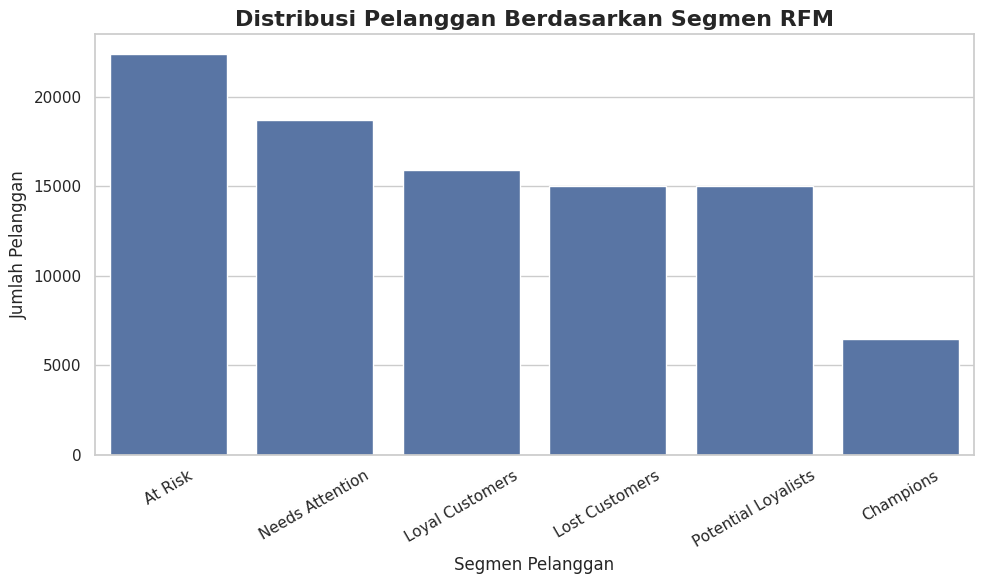

Segmen pelanggan terbesar: At Risk
Jumlah pelanggan: 22,357
Persentase: 23.95%


In [10]:
# Menggabungkan data transaksi dengan identitas pelanggan unik
rfm_data = sales[
    [
        'customer_id',
        'order_id',
        'order_purchase_timestamp',
        'sales_value'
    ]
].merge(
    customers_clean[
        [
            'customer_id',
            'customer_unique_id'
        ]
    ],
    on='customer_id',
    how='left'
)

rfm_data = rfm_data.dropna(
    subset=['customer_unique_id']
)

snapshot_date = (
    rfm_data['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

# Menghitung RFM berdasarkan customer_unique_id
rfm = (
    rfm_data
    .groupby('customer_unique_id')
    .agg(
        Recency=(
            'order_purchase_timestamp',
            lambda x: (
                snapshot_date - x.max()
            ).days
        ),
        Frequency=(
            'order_id',
            'nunique'
        ),
        Monetary=(
            'sales_value',
            'sum'
        )
    )
    .reset_index()
)

# Memberikan skor RFM
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

def segment_customer(row):

    if (
        row['R_Score'] >= 4
        and row['F_Score'] >= 4
        and row['M_Score'] >= 4
    ):
        return 'Champions'

    elif (
        row['R_Score'] >= 4
        and row['F_Score'] >= 3
    ):
        return 'Loyal Customers'

    elif (
        row['R_Score'] >= 4
        and row['F_Score'] <= 2
    ):
        return 'Potential Loyalists'

    elif (
        row['R_Score'] <= 2
        and row['F_Score'] >= 3
    ):
        return 'At Risk'

    elif (
        row['R_Score'] <= 2
        and row['F_Score'] <= 2
    ):
        return 'Lost Customers'

    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

rfm_segment = (
    rfm['Segment']
    .value_counts()
    .reset_index()
)

rfm_segment.columns = [
    'Segment',
    'Customers'
]

rfm_segment['Percentage'] = (
    rfm_segment['Customers']
    / rfm_segment['Customers'].sum()
    * 100
)

display(rfm.head())
display(rfm_segment)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rfm_segment,
    x='Segment',
    y='Customers'
)

plt.title(
    'Distribusi Pelanggan Berdasarkan Segmen RFM',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Segmen Pelanggan')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

largest_segment = rfm_segment.iloc[0]

print(
    "Segmen pelanggan terbesar:",
    largest_segment['Segment']
)

print(
    f"Jumlah pelanggan: {int(largest_segment['Customers']):,}"
)

print(
    f"Persentase: {largest_segment['Percentage']:.2f}%"
)

**Insight:** (Opsional)

- RFM menggunakan `customer_unique_id` sehingga Frequency dapat menggambarkan jumlah transaksi aktual setiap pelanggan.
- Segmentasi membedakan pelanggan berdasarkan kebaruan transaksi, frekuensi transaksi, dan total nilai penjualan.
- Segmen **Champions** dan **Loyal Customers** dapat diprioritaskan untuk retensi.
- Segmen **At Risk** dan **Lost Customers** dapat menjadi target program reactivation.
- Jumlah dan persentase setiap segmen ditampilkan pada output sehingga dapat digunakan sebagai dasar strategi pelanggan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis penjualan bulanan, performa transaksi berubah sepanjang periode September 2016–Agustus 2018. Nilai penjualan tertinggi terjadi pada **November 2017**, dengan total nilai penjualan sebesar **R$ 1.153.364,20**.

- **Conclusion pertanyaan 2:** Kategori **health_beauty** menghasilkan nilai penjualan terbesar, yaitu **R$ 1.412.089,53**, dengan kontribusi sebesar **9,16%** terhadap total nilai penjualan.

- **Conclusion analisis lanjutan:** RFM Analysis dilakukan menggunakan `customer_unique_id` untuk mengelompokkan pelanggan berdasarkan Recency, Frequency, dan Monetary. Segmen pelanggan dengan nilai tinggi menjadi prioritas retensi, sedangkan pelanggan pada segmen `At Risk` dan `Lost Customers` dapat menjadi target strategi reactivation.

**Rekomendasi Action Item:**

- Menggunakan **November 2017** sebagai salah satu benchmark untuk mengevaluasi faktor yang mendorong tingginya nilai penjualan dan merancang campaign pada periode dengan potensi permintaan tinggi.
- Memprioritaskan kategori **health_beauty** dalam strategi promosi, pengelolaan stok, dan penawaran produk karena memberikan kontribusi nilai penjualan terbesar.
- Memberikan program loyalitas atau penawaran khusus kepada pelanggan pada segmen **Champions** dan **Loyal Customers**.
- Melakukan campaign reactivation yang lebih terarah kepada pelanggan pada segmen **At Risk** dan **Lost Customers**.
- Menggunakan dashboard untuk memantau tren penjualan, kategori produk, dan segmentasi pelanggan secara berkala sehingga keputusan bisnis dapat dibuat berdasarkan data.